# Paso 1: Importacion de los datos y configuracion general

In [3]:
# Imports y Configuración General

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# ── Rutas de entrada ──────────────────────────────────────────────────────────
PATH_TRAIN  = "../../data/processed/Split_Datasets/data_train_clean.csv"
PATH_VAL    = "../../data/processed/Split_Datasets/data_val_clean.csv"
PATH_TEST   = "../../data/processed/Split_Datasets/data_test_clean.csv"
PATH_SCALER = "../../data/processed/scaler_m30.pkl"

# ── Constantes del pipeline (heredadas del dataloader de tu compañero) ────────
N_FEATURES  = 19      # features por timestep tras preprocesamiento
SIGNAL_COLS = None    # se define en Paso 2 tras leer los CSVs
FEATURE_COLS = None   # se define en Paso 3 tras codificación cíclica

print("✅ Paso 1 completado.")

Dispositivo: cpu
✅ Paso 1 completado.


# Paso 2: Carga y normalizacion de los datos

In [4]:
# PASO 2: Carga de datos y normalización

# ── 2.1 Carga de los tres splits ──────────────────────────────────────────────
df_train = pd.read_csv(PATH_TRAIN, index_col=0, parse_dates=True)
df_val   = pd.read_csv(PATH_VAL,   index_col=0, parse_dates=True)
df_test  = pd.read_csv(PATH_TEST,  index_col=0, parse_dates=True)

print(f"Train : {df_train.shape} | {df_train.index.min()} → {df_train.index.max()}")
print(f"Val   : {df_val.shape}   | {df_val.index.min()}   → {df_val.index.max()}")
print(f"Test  : {df_test.shape}  | {df_test.index.min()}  → {df_test.index.max()}")

# ── 2.2 Definir columnas de señal física (las que se normalizan) ──────────────
SIGNAL_COLS = [
    'intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782',
    'ocupacion_3820',  'ocupacion_6642',  'ocupacion_6676',  'ocupacion_6782',
    'vmed_3820',       'vmed_6642',       'vmed_6676',       'vmed_6782'
]  # 12 columnas — coincide con el dataloader de tu compañero

# ── 2.3 Ajustar scaler SOLO en train, aplicar a val y test ───────────────────
scaler = StandardScaler()
df_train[SIGNAL_COLS] = scaler.fit_transform(df_train[SIGNAL_COLS])
df_val[SIGNAL_COLS]   = scaler.transform(df_val[SIGNAL_COLS])
df_test[SIGNAL_COLS]  = scaler.transform(df_test[SIGNAL_COLS])

# ── 2.4 Guardar scaler en disco ───────────────────────────────────────────────
with open(PATH_SCALER, 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n✅ Scaler ajustado sobre {len(df_train)} filas de train.")
print(f"   Guardado en: {PATH_SCALER}")
print(f"   Columnas normalizadas: {len(SIGNAL_COLS)}")
print(f"\n✅ Paso 2 completado.")

Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00   → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00  → 2026-02-28 23:00:00

✅ Scaler ajustado sobre 16080 filas de train.
   Guardado en: ../../data/processed/scaler_m30.pkl
   Columnas normalizadas: 12

✅ Paso 2 completado.


# Paso 3: Codificacion ciclica y construccion del Dataset

In [5]:
# PASO 3: Codificación cíclica y construcción del Dataset

# ── 3.1 Codificación cíclica de variables temporales ─────────────────────────
def agregar_ciclicas(df):
    """
    Convierte hora, dia_semana y mes a pares seno/coseno.
    Elimina las columnas originales para evitar duplicados.
    """
    df = df.copy()
    df['hora_sin']     = np.sin(2 * np.pi * df['hora']       / 24)
    df['hora_cos']     = np.cos(2 * np.pi * df['hora']       / 24)
    df['dia_sin']      = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_cos']      = np.cos(2 * np.pi * df['dia_semana'] / 7)
    df['mes_sin']      = np.sin(2 * np.pi * df['mes']        / 12)
    df['mes_cos']      = np.cos(2 * np.pi * df['mes']        / 12)
    df.drop(columns=['hora', 'dia_semana', 'mes'], inplace=True)
    return df

df_train = agregar_ciclicas(df_train)
df_val   = agregar_ciclicas(df_val)
df_test  = agregar_ciclicas(df_test)

# ── 3.2 Definir y verificar el orden de features ──────────────────────────────
FEATURE_COLS = SIGNAL_COLS + [
    'hora_sin', 'hora_cos',
    'dia_sin',  'dia_cos',
    'mes_sin',  'mes_cos',
    'es_finde'
]  # 12 señales + 6 cíclicas + 1 binaria = 19 features

assert len(FEATURE_COLS) == N_FEATURES, \
    f"Se esperaban {N_FEATURES} features, se obtuvieron {len(FEATURE_COLS)}"

print(f"Features por timestep : {len(FEATURE_COLS)}")
print(f"Columnas tras preprocesamiento (train): {df_train.shape[1]}")

# ── 3.3 Clase Dataset con ventana deslizante (Direct Forecasting) ─────────────
class M30Dataset(Dataset):
    """
    Genera pares (X, y) con ventana deslizante.

    X : tensor (input_len, n_features)  — ventana de entrada
    y : escalar float                   — valor de target en t + horizon

    Parámetros
    ----------
    df         : DataFrame ya normalizado y con cíclicas
    input_len  : tamaño de la ventana de entrada en horas (48 ó 168)
    horizon    : pasos adelante a predecir (1, 24 ó 168)
    target_col : columna objetivo (una de las 4 intensidades)
    """
    def __init__(self, df, input_len, horizon, target_col):
        self.input_len  = input_len
        self.horizon    = horizon
        self.target_col = target_col

        # Arrays numpy para acceso eficiente
        self.X_data = df[FEATURE_COLS].values.astype(np.float32)
        self.y_data = df[target_col].values.astype(np.float32)

        # Índices válidos: ventana completa + horizonte caben en el DataFrame
        self.indices = [
            i for i in range(len(df) - input_len - horizon + 1)
            if not np.isnan(self.X_data[i : i + input_len]).any()
            and not np.isnan(self.y_data[i + input_len + horizon - 1])
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i   = self.indices[idx]
        X   = self.X_data[i : i + self.input_len]
        y   = self.y_data[i + self.input_len + self.horizon - 1]
        return torch.tensor(X), torch.tensor(y)

# ── 3.4 Función para instanciar los tres DataLoaders de una vez ───────────────
def crear_dataloaders(input_len, horizon, target_col, batch_size=32):
    """
    Devuelve (dl_train, dl_val, dl_test) listos para entrenamiento.
    """
    ds_train = M30Dataset(df_train, input_len, horizon, target_col)
    ds_val   = M30Dataset(df_val,   input_len, horizon, target_col)
    ds_test  = M30Dataset(df_test,  input_len, horizon, target_col)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)

    print(f"  Train : {len(ds_train):>6} ventanas")
    print(f"  Val   : {len(ds_val):>6} ventanas")
    print(f"  Test  : {len(ds_test):>6} ventanas")

    return dl_train, dl_val, dl_test

# ── 3.5 Verificación rápida con una configuración de ejemplo ──────────────────
print("\n── Verificación con input=48h | horizon=1h | target=intensidad_3820 ──")
dl_train_test, dl_val_test, dl_test_test = crear_dataloaders(
    input_len  = 48,
    horizon    = 1,
    target_col = 'intensidad_3820',
    batch_size = 32
)

X_sample, y_sample = next(iter(dl_train_test))
print(f"\n  Shape X (batch): {X_sample.shape}  → (batch_size, input_len, n_features)")
print(f"  Shape y (batch): {y_sample.shape}  → (batch_size,)")
print(f"  Dtype X: {X_sample.dtype} | Dtype y: {y_sample.dtype}")

print("\n✅ Paso 3 completado.")

Features por timestep : 19
Columnas tras preprocesamiento (train): 19

── Verificación con input=48h | horizon=1h | target=intensidad_3820 ──
  Train :  16032 ventanas
  Val   :   1416 ventanas
  Test  :   1368 ventanas

  Shape X (batch): torch.Size([32, 48, 19])  → (batch_size, input_len, n_features)
  Shape y (batch): torch.Size([32])  → (batch_size,)
  Dtype X: torch.float32 | Dtype y: torch.float32

✅ Paso 3 completado.


# Paso 4: Creamos arquitectura LSTM

In [6]:
# PASO 4: Arquitectura del modelo LSTM

class LSTMForecaster(nn.Module):
    """
    LSTM multivariable para forecasting de series de tiempo.

    Arquitectura
    ------------
    - Capa(s) LSTM apiladas con dropout entre capas
    - Capa fully-connected de proyección a la salida escalar

    Parámetros
    ----------
    input_size  : número de features por timestep (19)
    hidden_size : neuronas en cada capa LSTM
    num_layers  : número de capas LSTM apiladas
    dropout     : dropout aplicado entre capas LSTM (solo si num_layers > 1)
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMForecaster, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Núcleo LSTM
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True    # entrada: (batch, seq_len, features)
        )

        # Capa de salida: del último hidden state → escalar
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch_size, input_len, input_size)

        # Inicializar estados ocultos en cero
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Paso por el LSTM
        # out: (batch_size, input_len, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Tomamos solo el último timestep
        out = out[:, -1, :]           # (batch_size, hidden_size)

        # Proyección a escalar
        out = self.fc(out)            # (batch_size, 1)
        return out.squeeze(1)         # (batch_size,)

# ── 4.1 Hiperparámetros de la arquitectura ────────────────────────────────────
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2

# ── 4.2 Instanciar y mover al dispositivo ─────────────────────────────────────
model = LSTMForecaster(
    input_size  = N_FEATURES,    # 19
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(DEVICE)

# ── 4.3 Resumen del modelo ────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nParámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"\n✅ Paso 4 completado.")

LSTMForecaster(
  (lstm): LSTM(19, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parámetros totales    : 208,513
Parámetros entrenables: 208,513

✅ Paso 4 completado.


# Paso 5: Loop de entrenamiento

In [7]:
# PASO 5: Loop de entrenamiento

# ── 5.1 Hiperparámetros de entrenamiento ──────────────────────────────────────
LEARNING_RATE = 1e-3
N_EPOCHS      = 50
PATIENCE      = 10       # Early stopping: épocas sin mejora antes de parar

# ── 5.2 Función de pérdida y optimizador ──────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── 5.3 Loop de entrenamiento con Early Stopping ──────────────────────────────
def entrenar_modelo(model, dl_train, dl_val, criterion, optimizer,
                    n_epochs=N_EPOCHS, patience=PATIENCE):
    """
    Entrena el modelo con early stopping sobre la pérdida de validación.

    Retorna
    -------
    history : dict con listas 'train_loss' y 'val_loss' por época
    """
    history        = {'train_loss': [], 'val_loss': []}
    best_val_loss  = np.inf
    best_weights   = None
    epochs_no_impr = 0

    for epoch in range(1, n_epochs + 1):

        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in dl_train:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(dl_train.dataset)

        # ── Fase de validación ────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in dl_val:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_pred  = model(X_batch)
                loss    = criterion(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(dl_val.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # ── Early stopping ────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_impr = 0
        else:
            epochs_no_impr += 1

        # ── Log cada 5 épocas ─────────────────────────────────────────────────
        if epoch % 5 == 0 or epoch == 1:
            marca = " ◀ mejor" if epochs_no_impr == 0 else ""
            print(f"  Época {epoch:>3}/{n_epochs} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f}{marca}")

        if epochs_no_impr >= patience:
            print(f"\n  Early stopping en época {epoch} "
                  f"(sin mejora por {patience} épocas).")
            break

    # Restaurar los mejores pesos
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
    print(f"\n  Mejor Val Loss: {best_val_loss:.6f}")
    return history

# ── 5.4 Verificación: entrenamiento con una configuración de ejemplo ───────────
print("── Entrenamiento: input=48h | horizon=1h | target=intensidad_3820 ──\n")

dl_train_ej, dl_val_ej, dl_test_ej = crear_dataloaders(
    input_len  = 48,
    horizon    = 1,
    target_col = 'intensidad_3820',
    batch_size = 32
)

# Reiniciar pesos del modelo para este experimento
torch.manual_seed(SEED)
model = LSTMForecaster(
    input_size  = N_FEATURES,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = entrenar_modelo(model, dl_train_ej, dl_val_ej, criterion, optimizer)

print("\n✅ Paso 5 completado.")

── Entrenamiento: input=48h | horizon=1h | target=intensidad_3820 ──

  Train :  16032 ventanas
  Val   :   1416 ventanas
  Test  :   1368 ventanas
  Época   1/50 | Train Loss: 0.099281 | Val Loss: 0.060453 ◀ mejor
  Época   5/50 | Train Loss: 0.027349 | Val Loss: 0.042347 ◀ mejor
  Época  10/50 | Train Loss: 0.022352 | Val Loss: 0.038941 ◀ mejor
  Época  15/50 | Train Loss: 0.019110 | Val Loss: 0.039379
  Época  20/50 | Train Loss: 0.016882 | Val Loss: 0.036563
  Época  25/50 | Train Loss: 0.015038 | Val Loss: 0.039286
  Época  30/50 | Train Loss: 0.013141 | Val Loss: 0.040949
  Época  35/50 | Train Loss: 0.011499 | Val Loss: 0.039405

  Early stopping en época 38 (sin mejora por 10 épocas).

  Mejor Val Loss: 0.033631

✅ Paso 5 completado.


# Paso 6: Evaluacion de las metricas

In [9]:
# PASO 6 (ACTUALIZADO): Evaluación con métricas (R², MAE, RMSE)

def evaluar_modelo(model, dl_train, dl_val, dl_test,
                   target_col, incluir_test=False):
    """
    Calcula R², MAE y RMSE en unidades reales.
    Por defecto evalúa solo Train y Val.
    Activar incluir_test=True únicamente en la evaluación final comparativa.
    """
    splits = [('Train', dl_train), ('Val', dl_val)]
    if incluir_test:
        splits.append(('Test', dl_test))

    resultados = {}

    for nombre, dl in splits:

        preds_norm, reales_norm = obtener_predicciones(model, dl, target_col)

        preds_real  = desnormalizar(preds_norm,  target_col)
        reales_real = desnormalizar(reales_norm, target_col)

        r2   = r2_score(reales_real, preds_real)
        mae  = mean_absolute_error(reales_real, preds_real)
        rmse = np.sqrt(mean_squared_error(reales_real, preds_real))

        resultados[nombre] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

    # ── Tabla de resultados ───────────────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  Métricas — target: {target_col}")
    if not incluir_test:
        print(f"  ⚠️  Test excluido — reservado para evaluación final")
    print(f"{'─'*55}")
    print(f"  {'Split':<8} {'R²':>10} {'MAE':>10} {'RMSE':>10}")
    print(f"{'─'*55}")
    for nombre, m in resultados.items():
        print(f"  {nombre:<8} {m['R2']:>10.4f} {m['MAE']:>10.2f} {m['RMSE']:>10.2f}")
    print(f"{'─'*55}")

    return resultados

# ── Re-evaluación del experimento de ejemplo (sin test) ───────────────────────
print("── Evaluación: input=48h | horizon=1h | target=intensidad_3820 ──")

metricas = evaluar_modelo(
    model        = model,
    dl_train     = dl_train_ej,
    dl_val       = dl_val_ej,
    dl_test      = dl_test_ej,
    target_col   = 'intensidad_3820',
    incluir_test = False           # ← default, nunca cambia durante desarrollo
)

print("\n✅ Paso 6 actualizado completado.")

── Evaluación: input=48h | horizon=1h | target=intensidad_3820 ──

───────────────────────────────────────────────────────
  Métricas — target: intensidad_3820
  ⚠️  Test excluido — reservado para evaluación final
───────────────────────────────────────────────────────
  Split            R²        MAE       RMSE
───────────────────────────────────────────────────────
  Train        0.9878     124.03     191.22
  Val          0.9713     223.54     317.79
───────────────────────────────────────────────────────

✅ Paso 6 actualizado completado.


# Paso 7: Visualizacion de las predicciones

── Visualización: input=48h | horizon=1h | target=intensidad_3820 ──



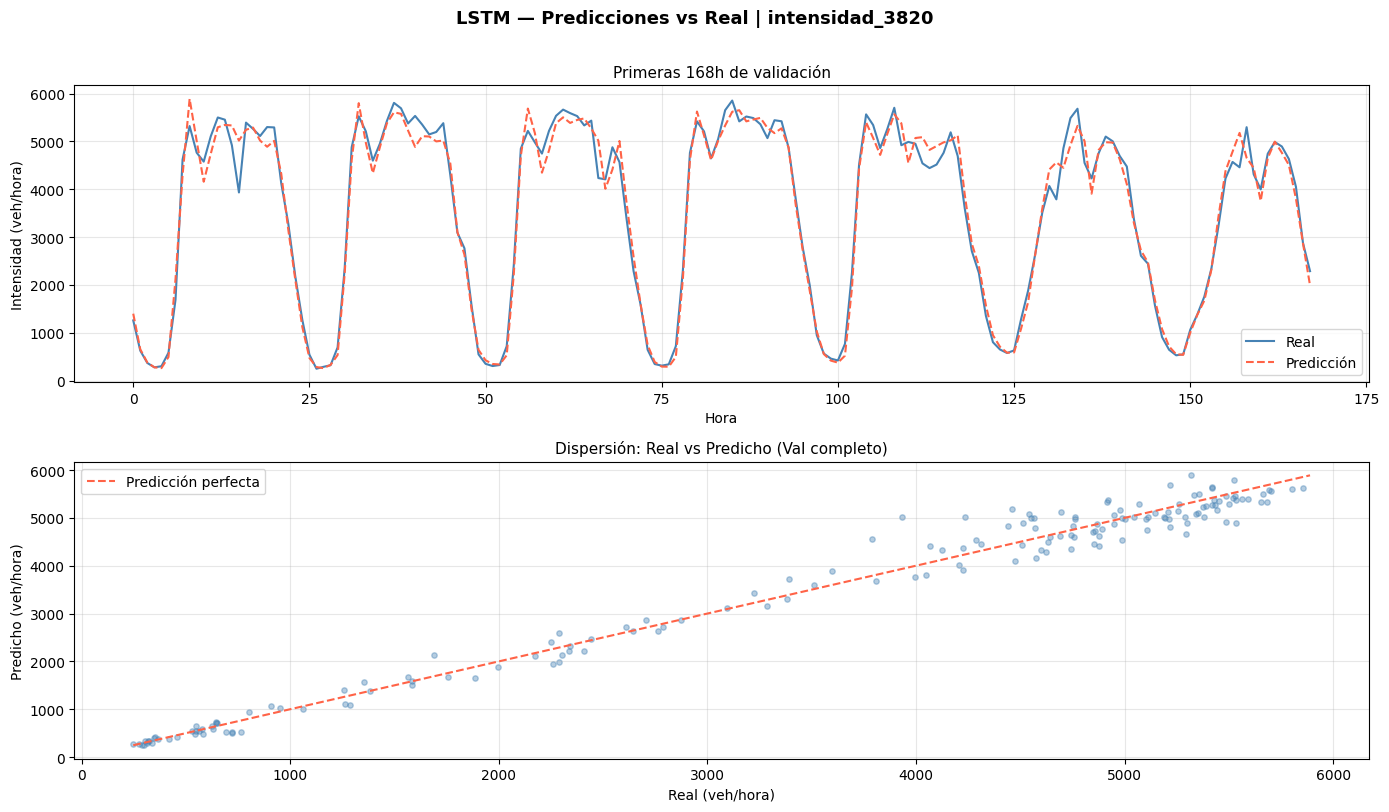

  Gráfico guardado: lstm_predicciones_val.png

✅ Paso 7 completado.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 7: Visualización de predicciones
# ─────────────────────────────────────────────────────────────────────────────

def visualizar_predicciones(model, dl_val, target_col, n_horas=168):
    """
    Grafica valores reales vs predicciones sobre las primeras n_horas
    del conjunto de validación.

    Parámetros
    ----------
    n_horas : ventana de visualización (default 168 = 1 semana)
    """
    # Obtener predicciones completas de validación
    preds_norm, reales_norm = obtener_predicciones(model, dl_val, target_col)

    # Desnormalizar
    preds_real  = desnormalizar(preds_norm,  target_col)
    reales_real = desnormalizar(reales_norm, target_col)

    # Recortar a n_horas
    preds_real  = preds_real[:n_horas]
    reales_real = reales_real[:n_horas]
    horas       = np.arange(n_horas)

    # ── Figura ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(
        f'LSTM — Predicciones vs Real | {target_col}',
        fontsize=13, fontweight='bold', y=1.01
    )

    # ── Panel superior: serie temporal ────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(horas, reales_real, label='Real',       color='steelblue',  lw=1.5)
    ax1.plot(horas, preds_real,  label='Predicción', color='tomato',
             lw=1.5, linestyle='--')
    ax1.set_title(f'Primeras {n_horas}h de validación', fontsize=11)
    ax1.set_xlabel('Hora')
    ax1.set_ylabel('Intensidad (veh/hora)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Panel inferior: dispersión real vs predicho ───────────────────────────
    ax2 = axes[1]
    ax2.scatter(reales_real, preds_real, alpha=0.4, s=15, color='steelblue')

    # Línea de predicción perfecta
    lim_min = min(reales_real.min(), preds_real.min())
    lim_max = max(reales_real.max(), preds_real.max())
    ax2.plot([lim_min, lim_max], [lim_min, lim_max],
             color='tomato', lw=1.5, linestyle='--', label='Predicción perfecta')

    ax2.set_title('Dispersión: Real vs Predicho (Val completo)', fontsize=11)
    ax2.set_xlabel('Real (veh/hora)')
    ax2.set_ylabel('Predicho (veh/hora)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('lstm_predicciones_val.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  Gráfico guardado: lstm_predicciones_val.png")

# ── 7.1 Visualización del experimento de ejemplo ─────
print("── Visualización: input=48h | horizon=1h | target=intensidad_3820 ──\n")

visualizar_predicciones(
    model      = model,
    dl_val     = dl_val_ej,
    target_col = 'intensidad_3820',
    n_horas    = 168
)

print("\n✅ Paso 7 completado.")